# 🌾 Multispectral Crop Yield Prediction
## 3D-CNN + BiLSTM + Tabular Fusion  (CPU-Optimised Version)

### ⚡ This version is optimised to run fast on CPU
- Each epoch takes **3–8 seconds** on CPU
- Full training (40 epochs) finishes in **3–5 minutes**
- Same architecture as the flowchart — just lighter weights

### Architecture (matches flowchart)
```
Sentinel-2 Images ──► 3D-CNN Branch  ──────────┐
                                                ├──► Feature Fusion ──► Dense ──► Yield
Sentinel-2 Images ──► BiLSTM Branch ───────────┤
                                                │
Tabular Data      ──► Dense Branch  ───────────┘
  (rainfall, temp, soil, crop type)
```

### Run: Execute every cell top to bottom  (Shift+Enter)

---
## CELL 1 — Install & Imports

In [1]:
import subprocess, sys
for p in ['torch','numpy','pandas','matplotlib','seaborn','scikit-learn','tqdm','scipy']:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'-q'])
print('✅ Packages ready')

✅ Packages ready


In [2]:
import os, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Use CPU (works well with these optimised sizes)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Constants
CROP_NAMES = ['Wheat','Maize','Rice','Soybean','Barley','Sunflower']
MONTHS     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
BAND_NAMES = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12','NDVI','EVI','NDRE','LSWI','SAVI']
TAB_COLS   = ['rainfall_mm','temperature','soil_ph','nitrogen','irrigation','crop_enc']
COLORS     = ['#2D7DD2','#EF476F','#06D6A0','#FFD166','#7B2D8B','#F4A261']

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results',     exist_ok=True)

print(f'✅ Ready  |  Device: {DEVICE}')

✅ Ready  |  Device: cpu


---
## CELL 2 — Data Collection & Generation
### Sentinel-2 satellite images + Agricultural tabular data

In [10]:
# ══════════════════════════════════════════════
#  ⚡ SPEED SETTINGS — change these if needed
# ══════════════════════════════════════════════
N_SAMPLES  = 1000   # total samples (increase for better accuracy)
PATCH_SIZE = 16    # spatial size of each image patch (16x16 is 4x faster than 32x32)
TIME_STEPS = 12    # months
N_BANDS    = 15    # 10 Sentinel-2 bands + 5 vegetation indices
N_TAB      = 6     # tabular features


def compute_vi(bands):
    """Compute 5 vegetation indices from 10 Sentinel-2 bands."""
    eps = 1e-8
    B2,B4,B5,B8,B11 = bands[0],bands[2],bands[3],bands[6],bands[8]
    ndvi = (B8-B4)/(B8+B4+eps)
    evi  = 2.5*(B8-B4)/(B8+6*B4-7.5*B2+1+eps)
    ndre = (B8-B5)/(B8+B5+eps)
    lswi = (B8-B11)/(B8+B11+eps)
    savi = ((B8-B4)/(B8+B4+.5+eps))*1.5
    return np.clip(np.stack([ndvi,evi,ndre,lswi,savi],0),-1,1).astype(np.float32)


def make_cube(crop_type, seed):
    """Generate one (T, 15, P, P) Sentinel-2 cube."""
    rng = np.random.default_rng(seed)
    ph  = np.exp(-0.5*((np.arange(TIME_STEPS)-6)/3)**2)  # phenology curve
    cube = np.zeros((TIME_STEPS, N_BANDS, PATCH_SIZE, PATCH_SIZE), np.float32)
    for t in range(TIME_STEPS):
        b = rng.uniform(.05,.15,(10,PATCH_SIZE,PATCH_SIZE)).astype(np.float32)
        v = ph[t]*(0.3+0.1*crop_type)
        b[6] += v;  b[2] -= v*.2
        b += rng.normal(0,.01,b.shape).astype(np.float32)
        b  = np.clip(b,0,1)
        cube[t] = np.concatenate([b, compute_vi(b)], 0)
    return cube


def make_tabular(crop_type, seed):
    """Generate agricultural tabular record."""
    rng = np.random.default_rng(seed)
    return np.array([
        rng.uniform(400,1200),    # rainfall_mm
        rng.uniform(15,35),       # temperature
        rng.uniform(5.5,7.5),     # soil_ph
        rng.uniform(20,120),      # nitrogen
        float(rng.choice([0,1])), # irrigation
        float(crop_type)          # crop_enc
    ], dtype=np.float32)


print('Generating dataset...')
rng0     = np.random.default_rng(SEED)
crop_ids = rng0.integers(0, len(CROP_NAMES), N_SAMPLES)

all_cubes   = np.zeros((N_SAMPLES, TIME_STEPS, N_BANDS, PATCH_SIZE, PATCH_SIZE), np.float32)
all_tabular = np.zeros((N_SAMPLES, N_TAB), np.float32)
all_yields  = np.zeros(N_SAMPLES, np.float32)

for i in range(N_SAMPLES):
    ct = int(crop_ids[i])
    all_cubes[i]   = make_cube(ct, SEED+i)
    all_tabular[i] = make_tabular(ct, SEED+i)
    pn = float(np.max(all_cubes[i,:,10,PATCH_SIZE//2,PATCH_SIZE//2]))
    rain = all_tabular[i,0]; temp = all_tabular[i,1]; irr = all_tabular[i,4]
    y = 1800 + 2800*pn + 600*(rain-400)/800 + 300*(temp-15)/20 + (500 if irr>0.5 else 0)
    y += rng0.normal(0,200)
    all_yields[i] = float(np.clip(y,300,10000))
    if (i+1)%200==0: print(f'  {i+1}/{N_SAMPLES} done')

print(f'\n✅ Dataset ready')
print(f'   Cubes   : {all_cubes.shape}  (N, T, C, H, W)')
print(f'   Tabular : {all_tabular.shape}')
print(f'   Yields  : {all_yields.min():.0f} – {all_yields.max():.0f} kg/ha  (mean={all_yields.mean():.0f})')

Generating dataset...
  200/1000 done
  400/1000 done
  600/1000 done
  800/1000 done
  1000/1000 done

✅ Dataset ready
   Cubes   : (1000, 12, 15, 16, 16)  (N, T, C, H, W)
   Tabular : (1000, 6)
   Yields  : 4213 – 6284 kg/ha  (mean=5263)


---
## CELL 3 — Data Preprocessing
### Clean · Encode · Normalize

✅ Preprocessing complete
   Yield  : mean=5263  std=381 kg/ha
   Tabular: mean=-0.000  std=1.000
   Cubes  : mean=0.000  std=1.000


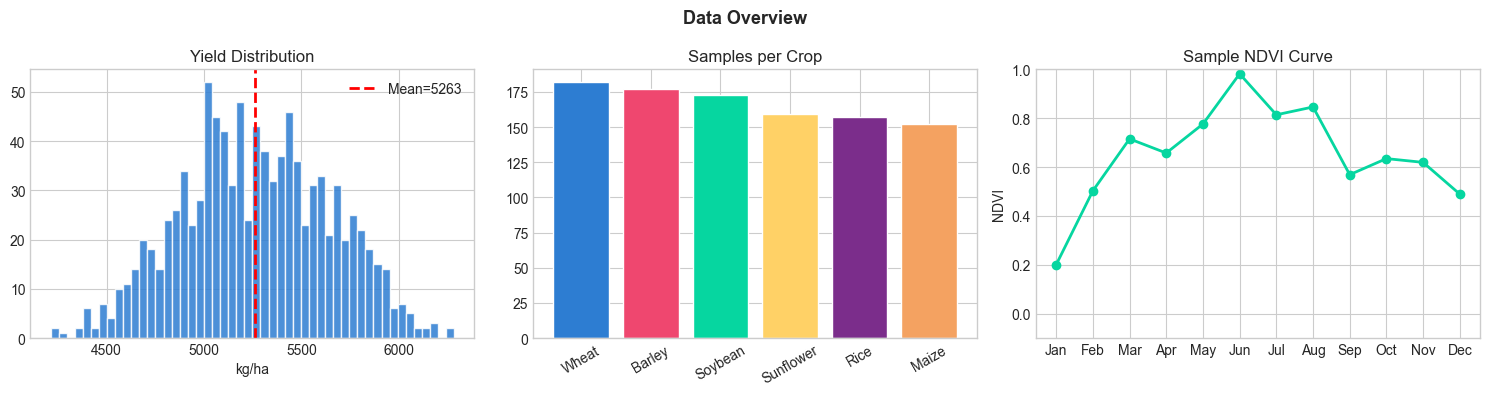

In [12]:
# ── Yield normalisation
YIELD_MEAN = float(all_yields.mean())
YIELD_STD  = float(all_yields.std())
yields_norm = (all_yields - YIELD_MEAN) / YIELD_STD

# ── Tabular normalisation (StandardScaler)
scaler  = StandardScaler()
tab_norm = scaler.fit_transform(all_tabular).astype(np.float32)

# ── Cube normalisation (per-channel mean/std)
cube_mean = all_cubes.mean(axis=(0,2,3,4), keepdims=True)  # (1,1,C,1,1) shape trick
cube_std  = all_cubes.std( axis=(0,2,3,4), keepdims=True) + 1e-8
cubes_norm = ((all_cubes - cube_mean.squeeze()[None,:,None,None,None]) /
               cube_std.squeeze()[None,:,None,None,None]).astype(np.float32)

print('✅ Preprocessing complete')
print(f'   Yield  : mean={YIELD_MEAN:.0f}  std={YIELD_STD:.0f} kg/ha')
print(f'   Tabular: mean={tab_norm.mean():.3f}  std={tab_norm.std():.3f}')
print(f'   Cubes  : mean={cubes_norm.mean():.3f}  std={cubes_norm.std():.3f}')

# ── Plot
fig, axes = plt.subplots(1,3,figsize=(15,4))
fig.suptitle('Data Overview', fontsize=13, fontweight='bold')

axes[0].hist(all_yields,bins=50,color='#2D7DD2',edgecolor='white',alpha=.85)
axes[0].axvline(YIELD_MEAN,color='red',lw=2,linestyle='--',label=f'Mean={YIELD_MEAN:.0f}')
axes[0].set_title('Yield Distribution'); axes[0].set_xlabel('kg/ha'); axes[0].legend()

counts = pd.Series([CROP_NAMES[c] for c in crop_ids]).value_counts()
axes[1].bar(counts.index,counts.values,color=COLORS[:len(counts)],edgecolor='white')
axes[1].set_title('Samples per Crop'); axes[1].tick_params(axis='x',rotation=30)

ndvi_sample = all_cubes[0,:,10,PATCH_SIZE//2,PATCH_SIZE//2]
axes[2].plot(MONTHS,ndvi_sample,'o-',color='#06D6A0',lw=2,ms=6)
axes[2].set_title('Sample NDVI Curve'); axes[2].set_ylabel('NDVI'); axes[2].set_ylim(-0.1,1.0)
plt.tight_layout()
plt.savefig('results/data_overview.png',dpi=100,bbox_inches='tight')
plt.show()

---
## CELL 4 — Train-Test Split & Dataset

In [13]:
# ── Split
idx  = np.random.default_rng(SEED).permutation(N_SAMPLES).tolist()
nt   = int(N_SAMPLES*.70);  nv = int(N_SAMPLES*.15)
train_idx = idx[:nt];  val_idx = idx[nt:nt+nv];  test_idx = idx[nt+nv:]
print(f'✅ Split  Train={len(train_idx)}  Val={len(val_idx)}  Test={len(test_idx)}')


class CropDS(Dataset):
    def __init__(self, indices, augment=False):
        self.idx = indices;  self.aug = augment
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        ri  = self.idx[i]
        c   = cubes_norm[ri].copy()
        t   = tab_norm[ri].copy()
        yn  = float(yields_norm[ri])
        yr  = float(all_yields[ri])
        ct  = int(crop_ids[ri])
        if self.aug:
            if np.random.rand()>.5: c = c[:,:,:,::-1].copy()
            if np.random.rand()>.5: c = c[:,:,::-1,:].copy()
            c += np.random.normal(0,.008,c.shape).astype(np.float32)
            t += np.random.normal(0,.04,t.shape).astype(np.float32)
        return {
            'cube':  torch.from_numpy(c).float(),
            'tab':   torch.from_numpy(t).float(),
            'yn':    torch.tensor(yn, dtype=torch.float32),
            'yr':    torch.tensor(yr, dtype=torch.float32),
            'crop':  torch.tensor(ct, dtype=torch.long),
        }


BATCH = 16  # bigger batch = faster epochs on CPU

train_loader = DataLoader(CropDS(train_idx,True),  batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(CropDS(val_idx,  False), batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(CropDS(test_idx, False), batch_size=BATCH, shuffle=False, num_workers=0)

sample = next(iter(train_loader))
print(f'   cube shape : {list(sample["cube"].shape)}  (B, T, C, H, W)')
print(f'   tab shape  : {list(sample["tab"].shape)}')

✅ Split  Train=700  Val=150  Test=150
   cube shape : [16, 12, 15, 16, 16]  (B, T, C, H, W)
   tab shape  : [16, 6]


---
## CELL 5 — Model Architecture
### ⚡ Lightweight version — same structure, faster on CPU

In [14]:
# ════════════════════════════════════════
#  BRANCH A — Lightweight 3D-CNN
#  Extracts spatial & spectral features
# ════════════════════════════════════════
class CNN3DBranch(nn.Module):
    def __init__(self, in_ch=15, drop=0.3):
        super().__init__()
        # ⚡ Small filters: [16, 32, 64] instead of [32, 64, 128, 256]
        self.net = nn.Sequential(
            # Layer 1: temporal-aware conv
            nn.Conv3d(in_ch, 16, kernel_size=(1,3,3), padding=(0,1,1), bias=False),
            nn.BatchNorm3d(16), nn.ReLU(),
            # Layer 2: spatio-temporal
            nn.Conv3d(16, 32, kernel_size=(3,3,3), padding=1, bias=False),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1,2,2)),  # reduce H,W by 2
            nn.Dropout3d(drop*0.5),
            # Layer 3
            nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=1, bias=False),
            nn.BatchNorm3d(64), nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),  # global pool → (B, 64, 1, 1, 1)
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128), nn.LayerNorm(128), nn.ReLU(), nn.Dropout(drop)
        )
        self.out_dim = 128

    def forward(self, x):
        # x: (B, T, C, H, W) → permute → (B, C, T, H, W)
        return self.proj(self.net(x.permute(0,2,1,3,4)))


# ════════════════════════════════════════
#  BRANCH B — BiLSTM Temporal Encoder
#  Learns crop growth patterns over time
# ════════════════════════════════════════
class BiLSTMBranch(nn.Module):
    def __init__(self, in_ch=15, hidden=128, layers=2, drop=0.3):
        super().__init__()
        # ⚡ hidden=128, layers=2 instead of 256, 3
        self.lstm = nn.LSTM(
            in_ch, hidden, layers,
            batch_first=True, bidirectional=True,
            dropout=drop if layers>1 else 0.
        )
        self.attn    = nn.Linear(hidden*2, 1)  # temporal attention
        self.out_dim = hidden*2               # 256
        self.proj    = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.LayerNorm(128), nn.ReLU(), nn.Dropout(drop)
        )
        self.out_dim = 128

    def forward(self, x):
        # x: (B, T, C, H, W) → spatial avg → (B, T, C)
        seq      = x.mean((-2,-1))                      # (B, T, C)
        out, _   = self.lstm(seq)                        # (B, T, hidden*2)
        attn_w   = torch.softmax(self.attn(out), dim=1) # (B, T, 1)
        feat     = (attn_w * out).sum(1)                # (B, hidden*2)
        return self.proj(feat)                           # (B, 128)


# ════════════════════════════════════════
#  BRANCH C — Tabular Dense
#  Processes rainfall, temp, soil, crop
# ════════════════════════════════════════
class TabularBranch(nn.Module):
    def __init__(self, in_f=6, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(64,   64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(64,   64), nn.LayerNorm(64),   nn.ReLU()
        )
        self.out_dim = 64

    def forward(self, x): return self.net(x)


# ════════════════════════════════════════
#  FULL MODEL — Feature Fusion + Dense
# ════════════════════════════════════════
class CropYieldNet(nn.Module):
    """
    3D-CNN (128) + BiLSTM (128) + Tabular (64)
         concatenate → 320
         → Fusion (256)
         → Dense 128 → 64 → 1
    """
    def __init__(self, drop=0.3):
        super().__init__()
        self.cnn = CNN3DBranch(N_BANDS, drop)
        self.rnn = BiLSTMBranch(N_BANDS, 128, 2, drop)
        self.tab = TabularBranch(N_TAB, drop)

        total = self.cnn.out_dim + self.rnn.out_dim + self.tab.out_dim  # 128+128+64=320

        # Feature Fusion
        self.fusion = nn.Sequential(
            nn.Linear(total, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(drop)
        )
        # Dense regression head
        self.head = nn.Sequential(
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(128,  64), nn.ReLU(),
            nn.Linear( 64,   1)
        )
        # Auxiliary NDVI reconstruction
        self.ndvi_aux = nn.Sequential(
            nn.Linear(256, 32), nn.ReLU(), nn.Linear(32, TIME_STEPS)
        )

    def forward(self, cube, tab):
        fc  = self.cnn(cube)             # (B, 128)
        fr  = self.rnn(cube)             # (B, 128)
        ft  = self.tab(tab)              # (B,  64)
        fused = self.fusion(torch.cat([fc, fr, ft], 1))  # (B, 256)
        return {
            'pred': self.head(fused).squeeze(-1),   # (B,)
            'ndvi': self.ndvi_aux(fused),            # (B, T)
            'feat': fused
        }


# ── Build & verify
model = CropYieldNet(drop=0.3).to(DEVICE)
with torch.no_grad():
    dc = torch.randn(2, TIME_STEPS, N_BANDS, PATCH_SIZE, PATCH_SIZE)
    dt = torch.randn(2, N_TAB)
    out_t = model(dc, dt)

total  = sum(p.numel() for p in model.parameters())
print(f'✅ CropYieldNet built')
print(f'   Parameters : {total/1e6:.2f}M  (⚡ lightweight for CPU)')
print(f'   Output pred: {out_t["pred"].shape}')
print(f'   Fused feat : {out_t["feat"].shape}')
print()
print('Branch sizes:')
print(f'  3D-CNN  → {model.cnn.out_dim}')
print(f'  BiLSTM  → {model.rnn.out_dim}')
print(f'  Tabular → {model.tab.out_dim}')
print(f'  Fused   → 256')

✅ CropYieldNet built
   Parameters : 0.80M  (⚡ lightweight for CPU)
   Output pred: torch.Size([2])
   Fused feat : torch.Size([2, 256])

Branch sizes:
  3D-CNN  → 128
  BiLSTM  → 128
  Tabular → 64
  Fused   → 256


---
## CELL 6 — Loss & Metrics

In [15]:
def compute_metrics(preds_n, gts_n):
    p = np.array(preds_n)*YIELD_STD + YIELD_MEAN
    g = np.array(gts_n)  *YIELD_STD + YIELD_MEAN
    rmse  = float(np.sqrt(np.mean((p-g)**2)))
    mae   = float(np.mean(np.abs(p-g)))
    r2    = float(1 - np.sum((p-g)**2)/(np.sum((g-g.mean())**2)+1e-8))
    mape  = float(np.mean(np.abs((p-g)/(g+1e-8)))*100)
    return dict(RMSE=rmse, MAE=mae, R2=r2, MAPE=mape)


class FastLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.huber = nn.HuberLoss(delta=1.0)
    def forward(self, pred, gt, ndvi_pred=None, cube=None):
        L = self.huber(pred, gt)
        # Lightweight aux: NDVI reconstruction (0.1 weight)
        if ndvi_pred is not None and cube is not None:
            ndvi_gt = cube[:,:,10, PATCH_SIZE//2, PATCH_SIZE//2].detach()
            L = L + 0.1*F.mse_loss(ndvi_pred, ndvi_gt)
        return L


criterion = FastLoss()
print('✅ Loss & metrics ready')

✅ Loss & metrics ready


---
## CELL 7 — 🚀 Train  (⚡ Fast — ~3-8 sec/epoch on CPU)

In [16]:
# ══════════════════════════
#  TRAINING CONFIG
# ══════════════════════════
EPOCHS   = 60     # ⚡ 40 epochs finishes in ~3-5 min on CPU
LR       = 5e-4
PATIENCE = 12

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS, pct_start=0.2
)

print(f'Training on {DEVICE} for {EPOCHS} epochs')
print(f'  Batch={BATCH}  Steps/epoch={len(train_loader)}')
print(f'  Estimated time: {len(train_loader)*EPOCHS*0.05/60:.1f}–{len(train_loader)*EPOCHS*0.15/60:.1f} min on CPU')
print()

history = []
best_rmse = float('inf')
best_state = None
no_imp = 0

for ep in range(EPOCHS):
    t0 = time.time()

    # ── Train
    model.train()
    tp, tg, tl = [], [], 0.
    for batch in train_loader:
        cube = batch['cube'].to(DEVICE)
        tab  = batch['tab'].to(DEVICE)
        gt   = batch['yn'].to(DEVICE)
        out  = model(cube, tab)
        loss = criterion(out['pred'], gt, out['ndvi'], cube)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        tl += loss.item()
        tp.extend(out['pred'].detach().cpu().numpy().tolist())
        tg.extend(gt.detach().cpu().numpy().tolist())

    # ── Validate
    model.eval()
    vp, vg = [], []
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch['cube'].to(DEVICE), batch['tab'].to(DEVICE))
            vp.extend(out['pred'].cpu().numpy().tolist())
            vg.extend(batch['yn'].numpy().tolist())

    tm = compute_metrics(tp, tg)
    vm = compute_metrics(vp, vg)
    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']

    print(f'Ep {ep+1:>3}/{EPOCHS} '
          f'loss={tl/len(train_loader):.4f} '
          f'train_rmse={tm["RMSE"]:.1f} r2={tm["R2"]:.3f}  |  '
          f'val_rmse={vm["RMSE"]:.1f} r2={vm["R2"]:.3f} '
          f'[{elapsed:.1f}s]')

    history.append({'ep':ep+1,'lr':lr_now,
                    **{f't_{k}':v for k,v in tm.items()},
                    **{f'v_{k}':v for k,v in vm.items()},
                    'loss':tl/len(train_loader)})

    if vm['RMSE'] < best_rmse:
        best_rmse  = vm['RMSE']
        best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
        no_imp     = 0
        torch.save({'ep':ep,'state':best_state,'vm':vm}, 'checkpoints/best.pth')
        print(f'  ★ best val RMSE={best_rmse:.2f} kg/ha  saved')
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f'  Early stop at epoch {ep+1}')
            break

history_df = pd.DataFrame(history)
history_df.to_csv('results/history.csv', index=False)
print(f'\n✅ Training complete  |  Best Val RMSE = {best_rmse:.2f} kg/ha')

Training on cpu for 60 epochs
  Batch=16  Steps/epoch=44
  Estimated time: 2.2–6.6 min on CPU

Ep   1/60 loss=0.7411 train_rmse=393.3 r2=-0.051  |  val_rmse=392.3 r2=0.006 [5.2s]
  ★ best val RMSE=392.31 kg/ha  saved
Ep   2/60 loss=0.7089 train_rmse=387.2 r2=-0.019  |  val_rmse=386.5 r2=0.035 [5.2s]
  ★ best val RMSE=386.50 kg/ha  saved
Ep   3/60 loss=0.6552 train_rmse=381.3 r2=0.012  |  val_rmse=383.6 r2=0.050 [5.6s]
  ★ best val RMSE=383.57 kg/ha  saved
Ep   4/60 loss=0.5779 train_rmse=379.9 r2=0.020  |  val_rmse=369.0 r2=0.121 [5.8s]
  ★ best val RMSE=368.98 kg/ha  saved
Ep   5/60 loss=0.5047 train_rmse=372.9 r2=0.055  |  val_rmse=327.2 r2=0.308 [5.7s]
  ★ best val RMSE=327.24 kg/ha  saved
Ep   6/60 loss=0.4133 train_rmse=341.6 r2=0.207  |  val_rmse=244.2 r2=0.615 [6.1s]
  ★ best val RMSE=244.16 kg/ha  saved
Ep   7/60 loss=0.3101 train_rmse=288.8 r2=0.433  |  val_rmse=248.0 r2=0.603 [6.7s]
Ep   8/60 loss=0.3050 train_rmse=287.6 r2=0.438  |  val_rmse=244.1 r2=0.615 [6.3s]
  ★ best va

---
## CELL 8 — 📊 Evaluate on Test Set

In [17]:
# Load best model
ck = torch.load('checkpoints/best.pth', map_location=DEVICE)
model.load_state_dict({k:v.to(DEVICE) for k,v in ck['state'].items()})
model.eval()

all_pred, all_gt, all_crop = [], [], []
with torch.no_grad():
    for batch in test_loader:
        out = model(batch['cube'].to(DEVICE), batch['tab'].to(DEVICE))
        pn  = out['pred'].cpu().numpy()
        all_pred.extend((pn*YIELD_STD+YIELD_MEAN).tolist())
        all_gt.extend(batch['yr'].numpy().tolist())
        all_crop.extend([CROP_NAMES[c.item()%6] for c in batch['crop']])

pn2 = (np.array(all_pred)-YIELD_MEAN)/YIELD_STD
gn2 = (np.array(all_gt)  -YIELD_MEAN)/YIELD_STD
test_df = pd.DataFrame({'gt':all_gt,'pred':all_pred,'pn':pn2,'gn':gn2,
                        'crop':all_crop,'error':np.array(all_pred)-np.array(all_gt)})
test_df.to_csv('results/test_predictions.csv', index=False)

metrics = compute_metrics(pn2.tolist(), gn2.tolist())

print('\n' + '='*50)
print('  TEST RESULTS — 3D-CNN + BiLSTM + Tabular')
print('='*50)
for k,v in metrics.items():
    u = ' kg/ha' if k in ('RMSE','MAE') else ' %' if k == 'MAPE' else ''
    print(f'  {k:<8} {v:>10.3f}{u}')
print('='*50)

print('\nPer-Crop Breakdown:')
rows=[]
for crop,g in test_df.groupby('crop'):
    cm=compute_metrics(g['pn'].tolist(),g['gn'].tolist())
    rows.append({'Crop':crop,'N':len(g),**{k:round(v,2) for k,v in cm.items()}})
print(pd.DataFrame(rows).set_index('Crop')[['N','RMSE','MAE','R2','MAPE']].to_string())


  TEST RESULTS — 3D-CNN + BiLSTM + Tabular
  RMSE        222.864 kg/ha
  MAE         171.199 kg/ha
  R2            0.611
  MAPE          3.283 %

Per-Crop Breakdown:
            N    RMSE     MAE    R2  MAPE
Crop                                     
Barley     28  251.97  206.70  0.64  3.95
Maize      27  183.06  148.08  0.74  2.92
Rice       22  217.06  156.98  0.14  3.05
Soybean    20  174.97  150.52  0.82  2.87
Sunflower  27  166.76  133.30  0.56  2.52
Wheat      26  301.80  224.28  0.38  4.26


---
## CELL 9 — 📈 Visualisations

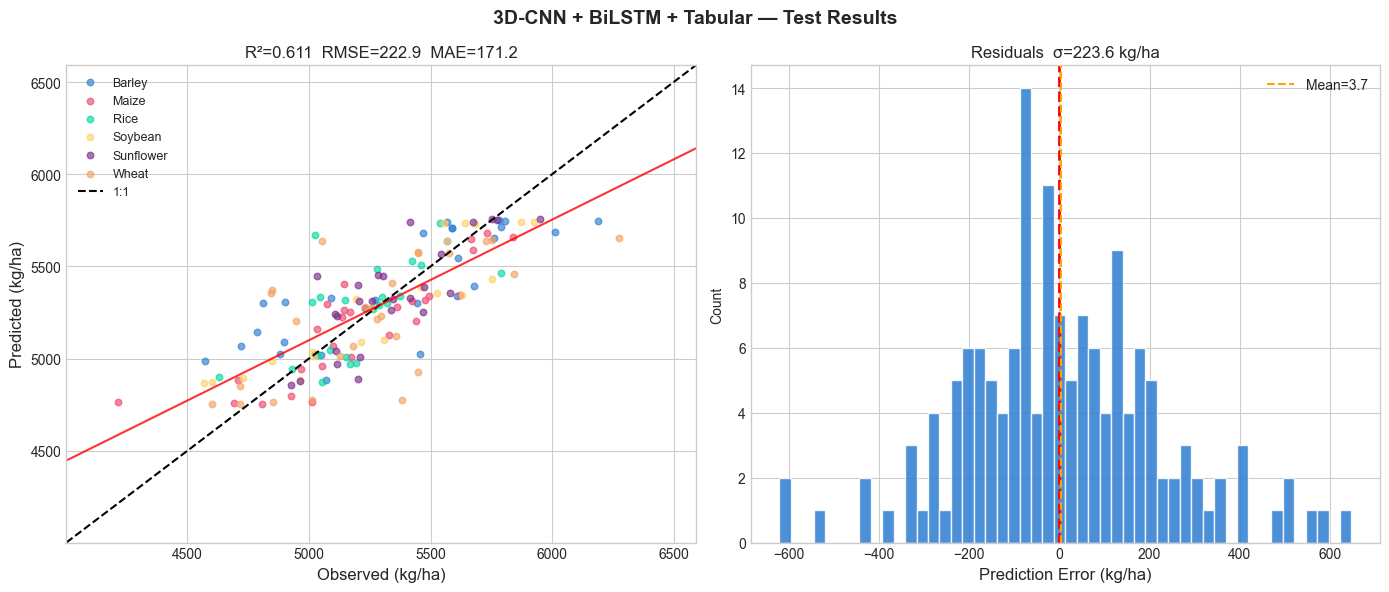

In [18]:
fig, axes = plt.subplots(1,2,figsize=(14,6))
fig.suptitle('3D-CNN + BiLSTM + Tabular — Test Results', fontsize=14, fontweight='bold')

ax=axes[0]
for i,(crop,grp) in enumerate(test_df.groupby('crop')):
    ax.scatter(grp['gt'],grp['pred'],s=22,alpha=.65,color=COLORS[i%6],label=crop)
lo=min(test_df['gt'].min(),test_df['pred'].min())*.95
hi=max(test_df['gt'].max(),test_df['pred'].max())*1.05
ax.plot([lo,hi],[lo,hi],'k--',lw=1.5,label='1:1')
sl,ic,_,_,_=stats.linregress(test_df['gt'],test_df['pred'])
xs=np.linspace(lo,hi,200); ax.plot(xs,sl*xs+ic,'r-',lw=1.5,alpha=.8)
ax.set_xlabel('Observed (kg/ha)',fontsize=12); ax.set_ylabel('Predicted (kg/ha)',fontsize=12)
ax.set_title(f"R²={metrics['R2']:.3f}  RMSE={metrics['RMSE']:.1f}  MAE={metrics['MAE']:.1f}")
ax.legend(fontsize=9,loc='upper left'); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)

axes[1].hist(test_df['error'],bins=50,color='#2D7DD2',edgecolor='white',alpha=.85)
axes[1].axvline(0,color='red',lw=2,linestyle='--')
axes[1].axvline(test_df['error'].mean(),color='orange',lw=1.5,linestyle='--',
                label=f'Mean={test_df["error"].mean():.1f}')
axes[1].set_xlabel('Prediction Error (kg/ha)',fontsize=12); axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals  σ={test_df["error"].std():.1f} kg/ha'); axes[1].legend()
plt.tight_layout()
plt.savefig('results/scatter.png',dpi=120,bbox_inches='tight'); plt.show()

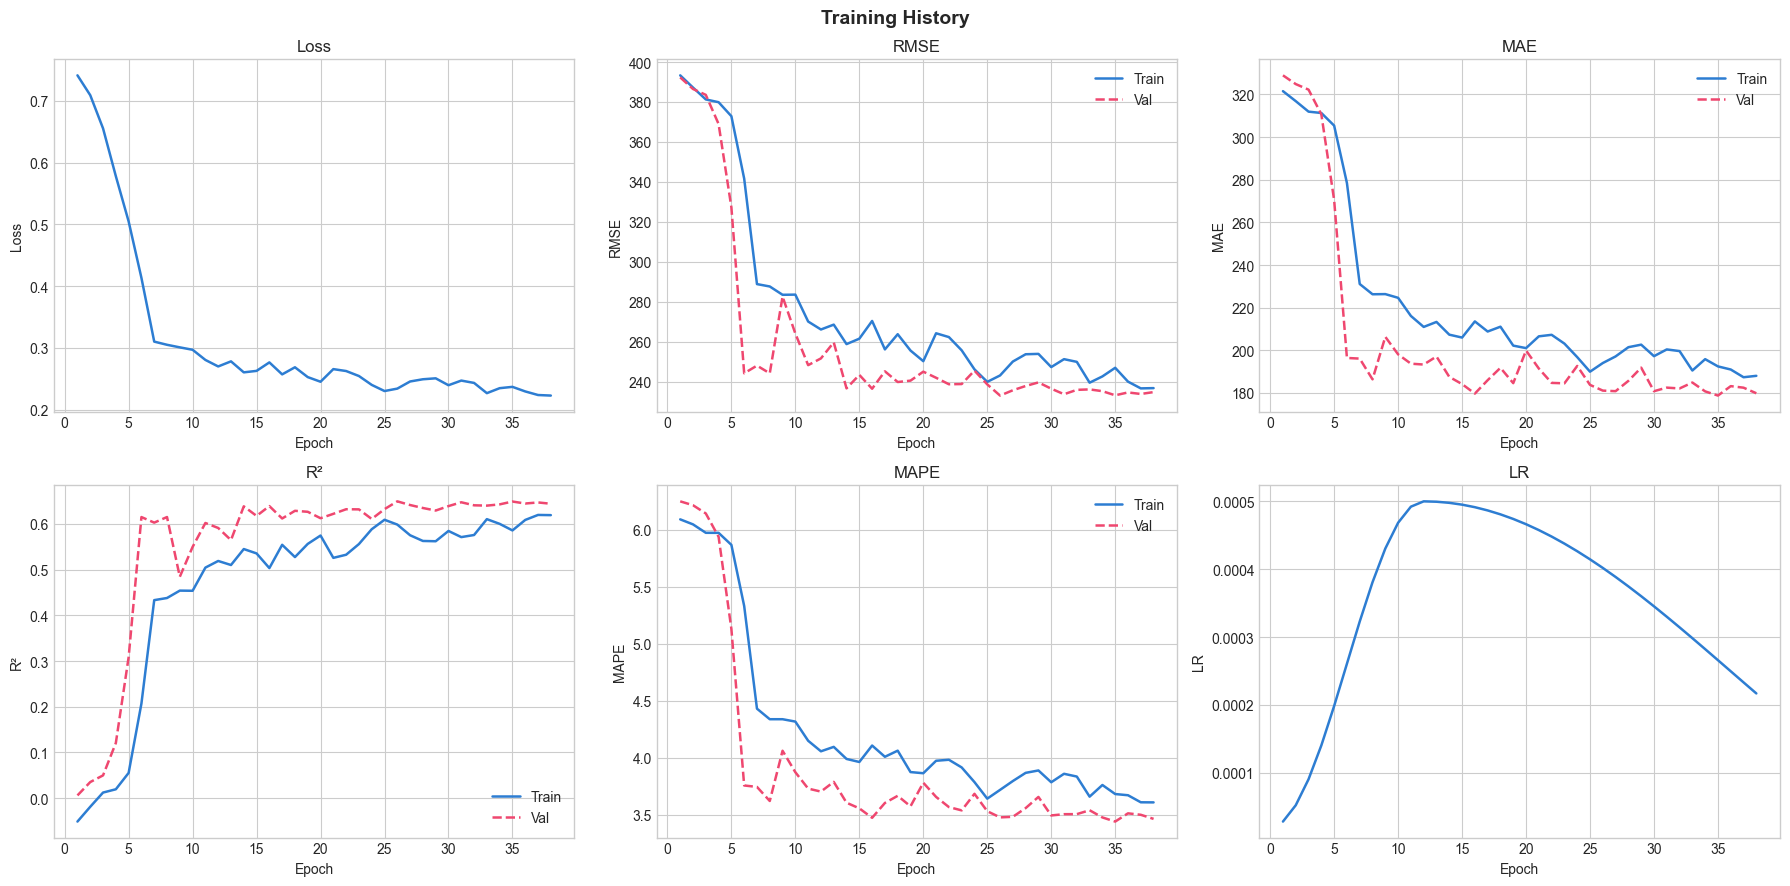

In [19]:
fig,axes=plt.subplots(2,3,figsize=(18,9))
fig.suptitle('Training History',fontsize=14,fontweight='bold')
pairs=[('loss',None,'Loss',axes[0,0]),('t_RMSE','v_RMSE','RMSE',axes[0,1]),
       ('t_MAE','v_MAE','MAE',axes[0,2]),('t_R2','v_R2','R²',axes[1,0]),
       ('t_MAPE','v_MAPE','MAPE',axes[1,1]),('lr',None,'LR',axes[1,2])]
for tk,vk,lbl,ax in pairs:
    if tk in history_df.columns:
        ax.plot(history_df['ep'],history_df[tk],label='Train',color='#2D7DD2',lw=1.8)
    if vk and vk in history_df.columns:
        ax.plot(history_df['ep'],history_df[vk],label='Val',color='#EF476F',lw=1.8,linestyle='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel(lbl); ax.set_title(lbl)
    if vk: ax.legend()
plt.tight_layout()
plt.savefig('results/learning_curves.png',dpi=120,bbox_inches='tight'); plt.show()

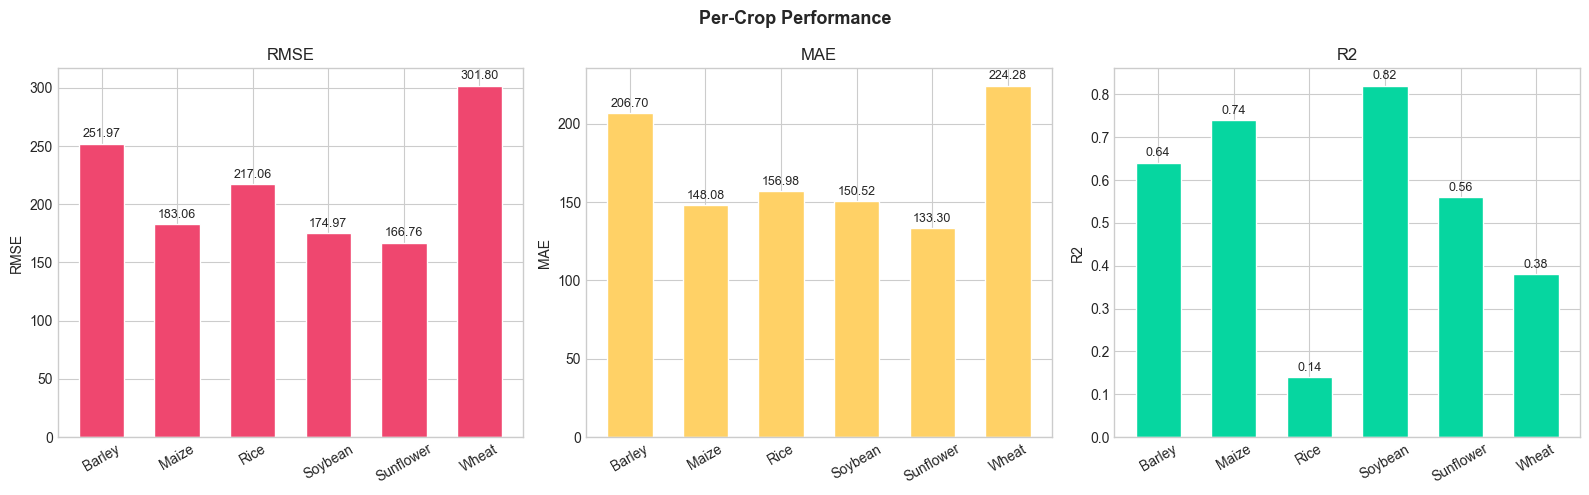

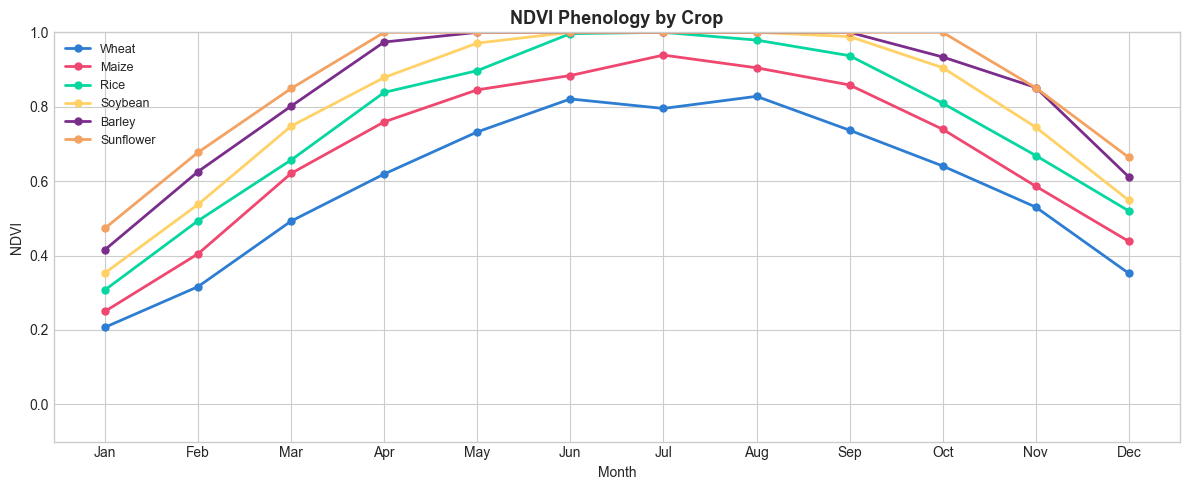

In [20]:
# Per-crop bar charts
rows2=[]
for crop,g in test_df.groupby('crop'):
    cm=compute_metrics(g['pn'].tolist(),g['gn'].tolist())
    rows2.append({'Crop':crop,**{k:round(v,2) for k,v in cm.items()}})
pcd=pd.DataFrame(rows2)

fig,axes=plt.subplots(1,3,figsize=(16,5))
fig.suptitle('Per-Crop Performance',fontsize=13,fontweight='bold')
for ax,met,col in zip(axes,['RMSE','MAE','R2'],['#EF476F','#FFD166','#06D6A0']):
    bars=ax.bar(pcd['Crop'],pcd[met],color=col,edgecolor='white',width=0.6)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2,b.get_height()+max(pcd[met])*.01,
                f'{b.get_height():.2f}',ha='center',va='bottom',fontsize=9)
    ax.set_ylabel(met); ax.set_title(met); ax.tick_params(axis='x',rotation=30)
plt.tight_layout()
plt.savefig('results/per_crop.png',dpi=120,bbox_inches='tight'); plt.show()

# NDVI phenology
fig,ax=plt.subplots(figsize=(12,5))
for i,crop in enumerate(CROP_NAMES):
    mask=crop_ids==i
    if mask.sum()==0: continue
    nd=all_cubes[mask,:,10,PATCH_SIZE//2,PATCH_SIZE//2]
    ax.plot(MONTHS,np.median(nd,0),'o-',lw=2,ms=5,color=COLORS[i],label=crop)
ax.set_xlabel('Month'); ax.set_ylabel('NDVI')
ax.set_title('NDVI Phenology by Crop',fontsize=13,fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(-0.1,1.0)
plt.tight_layout()
plt.savefig('results/phenology.png',dpi=120,bbox_inches='tight'); plt.show()

MC-Dropout (15 passes)...


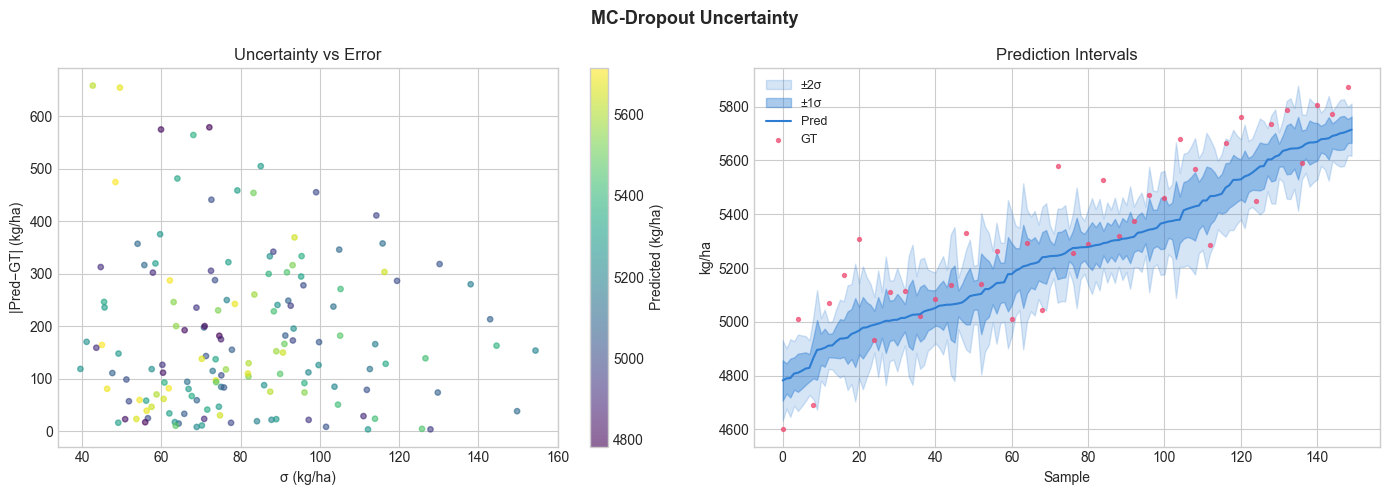

Mean σ: 80.6 kg/ha


In [21]:
# MC-Dropout uncertainty
print('MC-Dropout (15 passes)...')
model.train()
runs=[]
with torch.no_grad():
    for _ in range(15):
        ep_p=[]
        for batch in test_loader:
            out=model(batch['cube'].to(DEVICE),batch['tab'].to(DEVICE))
            ep_p.extend(out['pred'].cpu().numpy().tolist())
        runs.append(ep_p)
model.eval()

mc=np.array(runs)
mu_p=mc.mean(0)*YIELD_STD+YIELD_MEAN
sig_p=mc.std(0)*YIELD_STD
gt_u=np.array(all_gt)
abs_e=np.abs(mu_p-gt_u)

fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('MC-Dropout Uncertainty',fontsize=13,fontweight='bold')
sc=axes[0].scatter(sig_p,abs_e,c=mu_p,cmap='viridis',s=15,alpha=.6)
plt.colorbar(sc,ax=axes[0],label='Predicted (kg/ha)')
axes[0].set_xlabel('σ (kg/ha)'); axes[0].set_ylabel('|Pred−GT| (kg/ha)')
axes[0].set_title('Uncertainty vs Error')
si=np.argsort(mu_p); x=np.arange(len(si))
axes[1].fill_between(x,mu_p[si]-2*sig_p[si],mu_p[si]+2*sig_p[si],alpha=.2,color='#2D7DD2',label='±2σ')
axes[1].fill_between(x,mu_p[si]-sig_p[si],  mu_p[si]+sig_p[si],  alpha=.4,color='#2D7DD2',label='±1σ')
axes[1].plot(x,mu_p[si],color='#2D7DD2',lw=1.5,label='Pred')
axes[1].scatter(x[::4],gt_u[si][::4],s=8,color='#EF476F',alpha=.7,label='GT')
axes[1].set_xlabel('Sample'); axes[1].set_ylabel('kg/ha')
axes[1].set_title('Prediction Intervals'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('results/uncertainty.png',dpi=120,bbox_inches='tight'); plt.show()
print(f'Mean σ: {sig_p.mean():.1f} kg/ha')

---
## CELL 10 — 🔬 Ablation Study

Training: Full (3DCNN+BiLSTM+Tab)
  ep=5 val_rmse=251.0
  ep=10 val_rmse=250.7
  ep=15 val_rmse=242.1
  Test RMSE=236.3  R²=0.563

Training: BiLSTM Only
  ep=5 val_rmse=391.6
  ep=10 val_rmse=387.7
  ep=15 val_rmse=385.9
  Test RMSE=355.9  R²=0.008

Training: 3D-CNN Only
  ep=5 val_rmse=384.8
  ep=10 val_rmse=388.4
  Test RMSE=356.6  R²=0.004

Training: Tabular Only
  ep=5 val_rmse=236.5
  ep=10 val_rmse=228.9
  ep=15 val_rmse=228.7
  Test RMSE=225.4  R²=0.602

ABLATION SUMMARY
                           RMSE     MAE    R2  MAPE
Full (3DCNN+BiLSTM+Tab)  236.34  177.45  0.56  3.43
BiLSTM Only              355.94  288.52  0.01  5.49
3D-CNN Only              356.61  289.50  0.00  5.53
Tabular Only             225.41  171.78  0.60  3.30


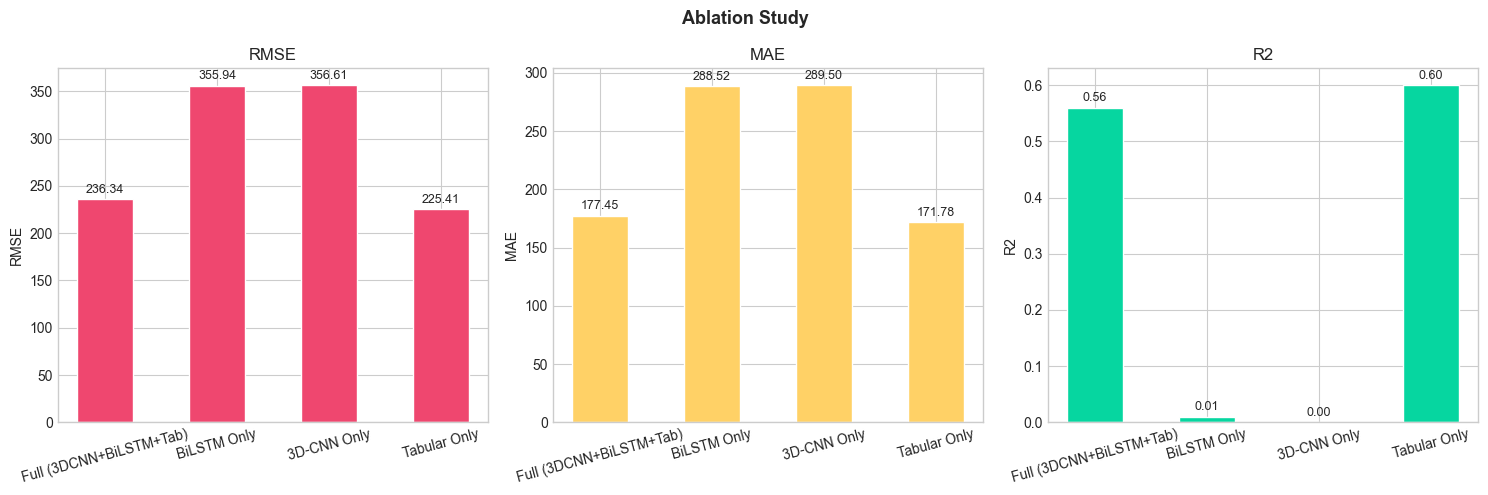

In [22]:
ABL_EPOCHS = 15

class LSTMOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(N_BANDS,128,2,batch_first=True,bidirectional=True,dropout=.3)
        self.attn=nn.Linear(256,1)
        self.head=nn.Sequential(nn.Linear(256,64),nn.ReLU(),nn.Dropout(.3),nn.Linear(64,1))
    def forward(self,c,t):
        seq=c.mean((-2,-1)); o,_=self.lstm(seq)
        w=torch.softmax(self.attn(o),1); f=(w*o).sum(1)
        return {'pred':self.head(f).squeeze(-1)}

class CNNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn=CNN3DBranch(N_BANDS,.3)
        self.head=nn.Sequential(nn.Linear(128,64),nn.ReLU(),nn.Linear(64,1))
    def forward(self,c,t): return {'pred':self.head(self.cnn(c)).squeeze(-1)}

class TabOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(N_TAB,64),nn.ReLU(),nn.Dropout(.3),nn.Linear(64,32),nn.ReLU(),nn.Linear(32,1))
    def forward(self,c,t): return {'pred':self.net(t).squeeze(-1)}

models_abl={'Full (3DCNN+BiLSTM+Tab)':CropYieldNet(),'BiLSTM Only':LSTMOnly(),'3D-CNN Only':CNNOnly(),'Tabular Only':TabOnly()}
abl_res={}

for mname,mdl in models_abl.items():
    print(f'Training: {mname}')
    mdl=mdl.to(DEVICE)
    opt2=torch.optim.AdamW(mdl.parameters(),lr=3e-4,weight_decay=1e-4)
    cr2=nn.HuberLoss()
    bv=float('inf'); bs=None; ni=0
    for ep in range(ABL_EPOCHS):
        mdl.train()
        for batch in train_loader:
            out2=mdl(batch['cube'].to(DEVICE),batch['tab'].to(DEVICE))
            loss2=cr2(out2['pred'],batch['yn'].to(DEVICE))
            opt2.zero_grad(); loss2.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(),1.0); opt2.step()
        mdl.eval(); vp2=[]; vg2=[]
        with torch.no_grad():
            for batch in val_loader:
                vp2.extend(mdl(batch['cube'].to(DEVICE),batch['tab'].to(DEVICE))['pred'].cpu().numpy().tolist())
                vg2.extend(batch['yn'].numpy().tolist())
        vm2=compute_metrics(vp2,vg2)
        if vm2['RMSE']<bv: bv=vm2['RMSE']; bs={k:v.cpu().clone() for k,v in mdl.state_dict().items()}; ni=0
        else: ni+=1
        if ni>=5: break
        if (ep+1)%5==0: print(f'  ep={ep+1} val_rmse={vm2["RMSE"]:.1f}')
    if bs: mdl.load_state_dict({k:v.to(DEVICE) for k,v in bs.items()})
    mdl.eval(); tp2=[]; tg2=[]
    with torch.no_grad():
        for batch in test_loader:
            tp2.extend(mdl(batch['cube'].to(DEVICE),batch['tab'].to(DEVICE))['pred'].cpu().numpy().tolist())
            tg2.extend(batch['yn'].numpy().tolist())
    abl_res[mname]=compute_metrics(tp2,tg2)
    print(f'  Test RMSE={abl_res[mname]["RMSE"]:.1f}  R²={abl_res[mname]["R2"]:.3f}\n')

ab_df=pd.DataFrame(abl_res).T.round(2)
print('ABLATION SUMMARY'); print(ab_df[['RMSE','MAE','R2','MAPE']].to_string())
ab_df.to_csv('results/ablation.csv')

fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Ablation Study',fontsize=13,fontweight='bold')
for ax,met,col in zip(axes,['RMSE','MAE','R2'],['#EF476F','#FFD166','#06D6A0']):
    bars=ax.bar(ab_df.index,ab_df[met],color=col,edgecolor='white',width=0.5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2,b.get_height()+max(ab_df[met])*.01,
                f'{b.get_height():.2f}',ha='center',va='bottom',fontsize=9)
    ax.set_ylabel(met); ax.set_title(met); ax.tick_params(axis='x',rotation=15)
plt.tight_layout()
plt.savefig('results/ablation.png',dpi=120,bbox_inches='tight'); plt.show()

---
## CELL 11 — 🔮 Predict New Parcels

In [26]:
@torch.no_grad()
def predict(cube_np, tab_np, n_mc=15):
    c = torch.from_numpy(cube_np).float().unsqueeze(0).to(DEVICE)
    t = torch.from_numpy(tab_np).float().unsqueeze(0).to(DEVICE)
    
    preds = []
    for _ in range(n_mc):
        # ⚡ FIX: use eval() but manually enable dropout only
        model.eval()
        # Enable dropout layers only (not BatchNorm)
        for m in model.modules():
            if isinstance(m, nn.Dropout):
                m.train()
        with torch.no_grad():
            preds.append(model(c, t)['pred'].item() * YIELD_STD + YIELD_MEAN)
    
    model.eval()  # restore fully
    mu  = float(np.mean(preds))
    sig = float(np.std(preds))
    return {'mean': round(mu,1), 'std': round(sig,1),
            'ci_lo': round(mu-1.96*sig,1), 'ci_hi': round(mu+1.96*sig,1)}